#  Calculation of features from available libraries

In [1]:
from Tools.DatasetTools.Commoms import *

In [2]:
sys.path.insert(0, '/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/')

dataset = 'Fe-Mo'  # 'Cr-Co-W' # 'Fe-Mo'#
components = dataset.split('-')
system=dataset.replace('-','')
from BopFoxFeaturizer.Featurizer import Featurizer

import Tools.DatasetTools.GeneralFeaturizer as gf

BS = pd.read_pickle(os.path.join(dataset, 'FullyCuratedParsedBriefSummary.pkl'))
AtomsObjects = pd.read_pickle(os.path.join(dataset, 'Atomsobjects', f'{system}-POSCAR-initial-rescaled-AtomsObjects.pkl')).dropna()
PymatgenStructures = pd.read_pickle(os.path.join(dataset, 'Atomsobjects', f'{system}-POSCAR-initial-rescaled-PymatgenStructures.pkl')).dropna()
SublatticeTags = pd.read_pickle(os.path.join(dataset,'Atomsobjects', 'SUBLATICETAGS.pkl'))
SublatticeSorters = pd.read_pickle(os.path.join(dataset,'Atomsobjects', 'SORTERS.pkl'))
SublatticeSorters.index = SublatticeSorters.index.str.strip()
SublatticeTags.index = SublatticeSorters.index.str.strip()

BS.dropna(inplace=True)

import numpy as np

# Prepare Extra features

In [3]:
from importlib.machinery import SourceFileLoader

In [4]:
from sklearn.preprocessing import  OneHotEncoder, LabelEncoder
encoder = LabelEncoder()

In [5]:
Featurizer = SourceFileLoader('Featurizer', '/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/Featurizer.py').load_module().Featurizer

In [6]:
Features = Featurizer(BS)

In [7]:
DatasetCompositionFeatures = Features.get_fractions_by_components()

In [8]:
#DatasetFeatures = pd.concat((DatasetCompositionFeatures, DatasetMagneticFeature, StructureNameFeature), axis=1)

##  Magnetism and structure

In [9]:
StructureNameFeature = BS.Phase
StructureNameFeature.name='Structure'
encoder.fit(StructureNameFeature)
DatasetStructureFeature = pd.Series(encoder.transform(StructureNameFeature), name='Structure', index = StructureNameFeature.index)

In [10]:
MagneticFeature = Features.MagFeature
MagneticFeature.name = 'Mag'
encoder.fit(MagneticFeature)
DatasetMagneticFeature = pd.Series(encoder.transform(MagneticFeature), name='Mag', index = StructureNameFeature.index)

In [11]:
DatasetFeatures = pd.concat([DatasetMagneticFeature, DatasetStructureFeature, DatasetCompositionFeatures, BS.num_atoms], axis = 1)

## Coordination Polyhedra feature

The first feature that we would like to have is the count of each CP in each sample. for that we construct a vector in the following way:

$$ N_{CN}^i = \#^i CP $$

Next feature we want is the composition in each CP. for this we choose to represent the elment numerically by their atomic numbers, and the CP-resolved composition becomes the average atomc numbers,

$$ Z_{CP} ^i = \dfrac{1}{n_{at}^i} \sum_{at \in CP} Z_{at} $$

In [12]:
SublatticeSorters

Fe-Mo/data/Fe_pv/POSCAR-initial/A15.FM/relax/xc=PBE-PAW.E=450.dk=0.020/POSCAR.initial                           [9, 10, 11, 12, 13, 14, 7, 8]
Fe-Mo/data/Fe_pv/POSCAR-initial/A15/relax/xc=PBE-PAW.E=450.dk=0.020/POSCAR.initial                              [9, 10, 11, 12, 13, 14, 7, 8]
Fe-Mo/data/Fe_pv/POSCAR-initial/C14.FM/relax/xc=PBE-PAW.E=450.dk=0.020/POSCAR.initial           [15, 16, 17, 18, 7, 8, 9, 10, 11, 12, 13, 14]
Fe-Mo/data/Fe_pv/POSCAR-initial/C14/relax/xc=PBE-PAW.E=450.dk=0.020/POSCAR.initial              [15, 16, 17, 18, 7, 8, 9, 10, 11, 12, 13, 14]
Fe-Mo/data/Fe_pv/POSCAR-initial/C15.FM/relax/xc=PBE-PAW.E=450.dk=0.020/POSCAR.initial                                   [7, 8, 9, 10, 11, 12]
                                                                                                                  ...                        
Fe-Mo/data/Mo_sv/POSCAR-initial/mu.FM/relax/xc=PBE-PAW.E=450.dk=0.020/POSCAR.initial        [7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Fe-Mo/

In [13]:
SortingFeatures = gf.sorting_feature(AtomsObjects, SublatticeSorters, SublatticeTags)
SortingFeatures.sorters = gf.correct_sortings_fromphases(AtomsObjects, BS.Phase, SortingFeatures.sorters)
SortingFeatures.sublatticetags = gf.correct_occupation_fromphases(BS.Phase, SortingFeatures.sublatticetags, AtomsObjects.atoms)
sampleinspecial = BS.Phase.map(lambda p: p in gf.specialphases)
empty = SortingFeatures.sublatticetags.map(lambda sublat: '' in sublat)
SortingFeatures.sublatticetags[empty] = ['A']
wrong = SortingFeatures.sublatticetags.map(lambda sublat: 'A' not in sublat) 
fixable = SortingFeatures.sublatticetags.loc[wrong].map(type) == np.ndarray #.map(np.unique)
CNList = gf.get_sitecn(BS.Phase, AtomsObjects.atoms, SortingFeatures.sorters)

  0%|          | 0/252 [00:00<?, ?it/s]

## Position Features

In [14]:
elements = np.unique(BS.filter(regex='^atom_').values.ravel())
ABOCC = pd.concat([BS.filter(regex='atom_'), Features.occupation], axis = 1)
ABOCC.rename(columns={ABOCC.columns[-1]: 'index'}, inplace=True)

In [15]:
Positions = {}
for index, item in ABOCC.iterrows():
    if item['index'] == '':
        thisposition = {index: [item[f'atom_A']]*len(np.unique(gf.cn_dict[BS.Phase[index]]))}
    else:
        thisposition = {index: [item[f'atom_{occ}'] for occ in item['index'] ]}
    Positions.update(thisposition)
Positions = pd.DataFrame.from_dict(Positions, orient='index')
Positions[Positions.isnull()] = 0
for i, element in enumerate(elements):
    Positions[Positions==element] = i
Positions.columns = [f'Pos_{col+1}' for col in Positions.columns]
#Positions[Positions.Pos_1.map(type) == str] = np.nan

## Averages over Coordination polyhedra

### Number of each CP in each structure

In [16]:
CN = gf.featurize_series(CNList, CNList, normalization='NCP', return0 = False)
newcolumns = ['N'+col for col in CN.columns]
CN.columns = newcolumns

### Composition and volume of the CP

In [17]:
from mendeleev import element

In [18]:
AtomicNumbers=AtomsObjects.atoms.map(lambda a: a.numbers)
AtomicNumbers.name = 'AtomicNumbers'
symbols = dataset.split('-')
volums = {symb: element(symb).atomic_volume for symb in symbols}

In [19]:
AtomicVolumes = AtomsObjects.atoms.map(lambda a: [volums[at] for at in a.get_chemical_symbols()])

In [20]:
CPVol = gf.featurize_series(AtomicVolumes, CNList, return0=False, normalization='NCP')
newcolumns = ['V'+col for col in CPVol.columns]
CPVol.columns =  newcolumns

In [21]:
CPComp = gf.featurize_series(AtomicNumbers, CNList, return0=False, normalization='NCP')
newcolumns = ['Z'+col for col in CPComp.columns]
CPComp.columns = newcolumns

## Compile all the descriptors

In [22]:
DatasetFeatures = pd.concat([DatasetStructureFeature, DatasetMagneticFeature, DatasetCompositionFeatures, CN, CPVol, CPComp, BS.num_atoms, Positions], axis=1)
datasetfeatureslocation = os.path.join(dataset, 'Descriptors','DatasetFeatures.pkl')
CNListlocation = os.path.join(dataset, 'Descriptors', 'CNList.pkl')
DatasetFeatures.to_pickle(datasetfeatureslocation)
CNList.to_pickle(CNListlocation)

# Matminer Features 

In [23]:
from Tools.DatasetTools.GetPymatgenFeatures import *

In [24]:
descriptorslocation = os.path.join(dataset, 'Descriptors')
mmflatomic = os.path.join(descriptorslocation, 'matminer_atomic_features.pkl')
mmfdensity = os.path.join (descriptorslocation, 'matminer_density_features.pkl')
mmfcomposition =  os.path.join (descriptorslocation,'matminer_composition_features.pkl')
mmfstructure =  os.path.join (descriptorslocation,'matminer_structure_features.pkl')
mmsoapfeatures = os.path.join(descriptorslocation, 'matminer_soap_features.pkl')


BS['chemical_formula'] = get_chemical_formula(BS)

In [25]:
BS['composition'] = StrToComposition().featurize_dataframe(BS, "chemical_formula")['composition']

StrToComposition:   0%|          | 0/252 [00:00<?, ?it/s]

In [26]:
BS['atoms_objects'] = PymatgenStructures

In [27]:
AtomicFeaturesMagpie = load_features(mmflatomic, BS, which='atomic')
DensitiFeatures= load_features(mmfdensity, BS, which='density')
CompositionFeatures = load_features(mmfcomposition, BS, which='composition')
# SOAP doesnt work from matminer
# StructureFeatures = load_features(mmfstructure, BS, which='structure')

In [28]:
AtomicFeaturesMagpie.columns = AtomicFeaturesMagpie.columns.str.replace('MagpieData ','')
AtomicFeaturesMagpie.dropna(axis=1, inplace = True)
AtomicFeaturesMagpie.describe()

,minimum Number,maximum Number,range Number,mean Number,avg_dev Number,mode Number,minimum MendeleevNumber,maximum MendeleevNumber,range MendeleevNumber,mean MendeleevNumber,...,range GSmagmom,mean GSmagmom,avg_dev GSmagmom,mode GSmagmom,minimum SpaceGroupNumber,maximum SpaceGroupNumber,range SpaceGroupNumber,mean SpaceGroupNumber,avg_dev SpaceGroupNumber,mode SpaceGroupNumber
count,278.000000,278.000000,278.000000,278.000000,278.000000,278.000000,278.000000,278.000000,278.000000,278.000000,...,278.000000,278.000000,278.000000,278.000000,278.0,278.0,278.0,278.0,278.0,278.0
mean,27.208633,40.906475,13.697842,34.032587,5.506825,33.482014,50.341727,54.622302,4.280576,52.489817,...,1.806970,1.051033,0.726441,1.017370,229.0,229.0,0.0,229.0,0.0,229.0
std,4.235785,4.044682,5.625695,4.473962,2.728751,7.997610,1.263963,1.323683,1.758030,1.398113,...,0.742122,0.590189,0.359967,1.056550,0.0,0.0,0.0,0.0,0.0,0.0
min,26.000000,26.000000,0.000000,26.000000,0.000000,26.000000,50.000000,50.000000,0.000000,50.000000,...,0.000000,0.000000,0.000000,0.000000,229.0,229.0,0.0,229.0,0.0,229.0
25%,26.000000,42.000000,16.000000,30.923077,4.444444,26.000000,50.000000,55.000000,5.000000,51.445936,...,2.110663,0.610377,0.586295,0.000000,229.0,229.0,0.0,229.0,0.0,229.0
50%,26.000000,42.000000,16.000000,34.000000,6.816568,26.000000,50.000000,55.000000,5.000000,52.500000,...,2.110663,1.055331,0.899217,0.000000,229.0,229.0,0.0,229.0,0.0,229.0
75%,26.000000,42.000000,16.000000,37.373004,7.762188,42.000000,50.000000,55.000000,5.000000,53.461538,...,2.110663,1.461228,1.023960,2.110663,229.0,229.0,0.0,229.0,0.0,229.0
max,42.000000,42.000000,16.000000,42.000000,8.000000,42.000000,55.000000,55.000000,5.000000,55.000000,...,2.110663,2.110663,1.055331,2.110663,229.0,229.0,0.0,229.0,0.0,229.0


In [29]:
DensitiFeatures.dropna(axis=1, inplace=True)
if DensitiFeatures.shape[1] > 0:
    DensitiFeatures.describe()

In [30]:
CompositionFeatures.dropna(axis=1, inplace=True)
CompositionFeatures.describe()

,HOMO_energy,LUMO_energy,gap_AO,band center,max ionic char,avg ionic char,0-norm,2-norm,3-norm,5-norm,7-norm,10-norm
count,278.000000,278.000000,278.000000,278.000000,278.000000,278.000000,278.000000,278.000000,278.000000,278.000000,278.000000,278.000000
mean,-0.191183,-0.187077,0.004106,3.975440,0.022993,0.004622,1.856115,0.803645,0.763849,0.742878,0.737115,0.734115
std,0.057334,0.054325,0.018231,0.031876,0.009443,0.002290,0.351606,0.100067,0.126469,0.143866,0.149616,0.152949
min,-0.295049,-0.295049,0.000000,3.918947,0.000000,0.000000,1.000000,0.707107,0.629961,0.574349,0.552045,0.535887
25%,-0.197978,-0.197978,0.000000,3.951583,0.026858,0.003730,2.000000,0.717540,0.648156,0.605448,0.593260,0.587983
50%,-0.153347,-0.153347,0.000000,3.975545,0.026858,0.005721,2.000000,0.757604,0.712002,0.694692,0.692646,0.692329
75%,-0.153347,-0.153347,0.000000,3.997530,0.026858,0.006515,2.000000,0.849837,0.835550,0.833387,0.833335,0.833333
max,-0.153347,-0.153347,0.097071,4.032960,0.026858,0.006714,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# ACE Features 

In [31]:
from ase.atoms import Atoms

In [32]:
def reset_symbols(a: Atoms, newsym : str = 'W'):
    newa = a.copy()
    natoms = newa.get_global_number_of_atoms()
    newsymbols = [newsym]*natoms
    newa.set_chemical_symbols(newsymbols)
    return newa

In [33]:
from importlib.machinery import SourceFileLoader

In [34]:
from Tools.DatasetTools.ACEDescriptors import MyPyACECalculator 
MyPyAceConfig = SourceFileLoader('ACEer', 'Tools/DatasetTools/ACEDescriptors.py').load_module().default_options_dict
MyPyACECalculator = SourceFileLoader('ACEer', 'Tools/DatasetTools/ACEDescriptors.py').load_module().MyPyACECalculator
default_options = SourceFileLoader('ACEer', 'Tools/DatasetTools/ACEDescriptors.py').load_module().default_options_dict

In [35]:
ACEer = MyPyACECalculator(components = components)

In [36]:
ACEFEATURES = AtomsObjects['atoms'].map(ACEer.get_ace_projections)
ACEFEATURES.name = 'ace_projections'

In [37]:
expand_ace = gf.array_expansions(ACEFEATURES.to_frame(),['ace_projections']) 

In [38]:
CNAV_ACE = gf.featurize_dataframe(expand_ace, CNList)

In [39]:
CNAV_ACE

,ace_projections_1_0,ace_projections_1_CN12,ace_projections_1_CN13,ace_projections_1_CN14,ace_projections_1_CN15,ace_projections_1_CN16,ace_projections_2_0,ace_projections_2_CN12,ace_projections_2_CN13,ace_projections_2_CN14,...,ace_projections_298_CN13,ace_projections_298_CN14,ace_projections_298_CN15,ace_projections_298_CN16,ace_projections_299_0,ace_projections_299_CN12,ace_projections_299_CN13,ace_projections_299_CN14,ace_projections_299_CN15,ace_projections_299_CN16
Fe_pv8Mo_sv22.sigma-BBABB.FM,1.358587,0.458449,0.000000,0.675649,0.224489,0.000000,0.668345,0.247514,0.000000,0.189746,...,0.000000,160.021440,42.146636,0.000000,837.209986,260.287944,0.000000,440.276929,136.645113,0.000000
Fe_pv10Mo_sv20.sigma-ABBAB.FM,1.675703,0.582091,0.000000,0.882795,0.210817,0.000000,0.925032,0.529329,0.000000,0.386689,...,0.000000,131.703731,30.734089,0.000000,553.734019,265.129570,0.000000,238.083573,50.520876,0.000000
Fe_pv4Mo_sv20.C36-ABBBB.FM,0.855780,0.539655,0.000000,0.000000,0.000000,0.316125,0.342262,0.094629,0.000000,0.000000,...,0.000000,0.000000,0.000000,91.705106,1508.949999,905.324694,0.000000,0.000000,0.000000,603.625305
Fe_pv5Mo_sv24.chi-AABB.FM,0.869870,0.262235,0.445296,0.000000,0.000000,0.162339,0.402492,-0.056501,0.323285,0.000000,...,123.574482,0.000000,0.000000,46.527515,1456.131613,507.344181,625.271266,0.000000,0.000000,323.516166
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,1.410505,0.742139,0.000000,0.282613,0.173041,0.212712,0.807362,0.578949,0.000000,0.154565,...,0.000000,66.770760,33.494646,37.675694,779.106780,450.492871,0.000000,171.882287,80.311415,76.420207
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv3Mo_sv10.mu-ABBBA.NM,1.170980,0.623739,0.000000,0.217348,0.174229,0.155665,0.571941,0.338117,0.000000,0.202797,...,0.000000,43.592167,39.070819,55.260432,1071.733017,570.673082,0.000000,215.160336,107.687202,178.212398
Fe_pv8Mo_sv22.sigma-BBABB.NM,1.358587,0.458449,0.000000,0.675649,0.224489,0.000000,0.668345,0.247514,0.000000,0.189746,...,0.000000,160.021440,42.146636,0.000000,837.209986,260.287944,0.000000,440.276929,136.645113,0.000000
Fe_pv1Mo_sv3.L12-AB3.FM,1.266315,1.266315,0.000000,0.000000,0.000000,0.000000,0.654181,0.654181,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,943.681436,943.681436,0.000000,0.000000,0.000000,0.000000
Fe_pv8Mo_sv22.sigma-BBBBA.FM,1.348016,0.419862,0.000000,0.749526,0.178629,0.000000,0.704065,0.135752,0.000000,0.594472,...,0.000000,163.749312,37.298778,0.000000,850.214612,228.324919,0.000000,536.862109,85.027584,0.000000


In [40]:
selection = CNAV_ACE[Features.StrucNames == 'bcc'].filter(regex='_0$')

In [41]:
selection

,ace_projections_1_0,ace_projections_2_0,ace_projections_3_0,ace_projections_4_0,ace_projections_5_0,ace_projections_6_0,ace_projections_7_0,ace_projections_8_0,ace_projections_9_0,ace_projections_10_0,...,ace_projections_290_0,ace_projections_291_0,ace_projections_292_0,ace_projections_293_0,ace_projections_294_0,ace_projections_295_0,ace_projections_296_0,ace_projections_297_0,ace_projections_298_0,ace_projections_299_0
Mo_sv1.bcc.FM,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,664.929282,-1.053179e-31,1.668125e-65,0.000000,0.0,0.0,0.0,0.0,3376.519974
Mo_sv1.bcc.NM,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,664.929282,-1.053179e-31,1.668125e-65,0.000000,0.0,0.0,0.0,0.0,3376.519974
Fe_pv1.bcc.NM,5.41163,2.852584,4.349957,1.372719,-2.520741,2.334577,5.685988,3.508318,5.585032,6.957543,...,0.0,0.000000,0.000000e+00,0.000000e+00,5942.724124,0.0,0.0,0.0,0.0,0.000000
Fe_pv1.bcc.FM,5.41163,2.852584,4.349957,1.372719,-2.520741,2.334577,5.685988,3.508318,5.585032,6.957543,...,0.0,0.000000,0.000000e+00,0.000000e+00,5942.724124,0.0,0.0,0.0,0.0,0.000000


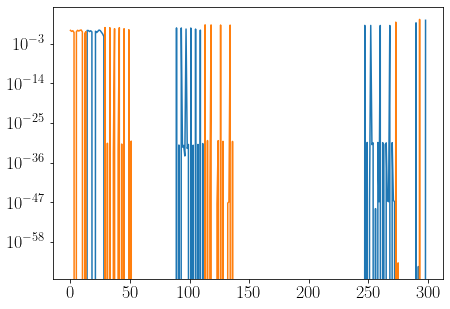

In [42]:
fig, ax = plt.subplots()
ax.plot(selection.iloc[0].values)
ax.plot(selection.iloc[2].values)
ax.set_yscale('log')

In [43]:
ACE_file = os.path.join(descriptorslocation, f'{dataset}-ACE-CNAV.pkl')

In [44]:
CNAV_ACE.to_pickle(ACE_file)

04_ComputeLibraryFeatures.ipynb## Canonical 

In [45]:
CanonicalAceConfig = copy.copy(MyPyAceConfig)

In [58]:
CanonicalAceConfig['elements'] = ['W']

In [60]:
CanonicalACEer = MyPyACECalculator(components = CanonicalAceConfig['elements'], multispace_basis_config=CanonicalAceConfig)

In [61]:
canonicalatomsobjects = AtomsObjects['atoms'].map(reset_symbols)

In [62]:
canonicalacedescriptors = canonicalatomsobjects.map(CanonicalACEer.get_ace_projections)

In [64]:
canonical_ACE_file = os.path.join(descriptorslocation, f'{dataset}-canonical-ACE-CNAV.pkl')

In [65]:
canonicalacedescriptors.to_pickle(canonical_ACE_file)

In [ ]:
new_multispace_config.update(
    {'embeddings':
     {
        'Fe': {
            'npot': 'FinnisSinclairShiftedScaled',
            'fs_parameters': [1, 1], ## non-linear embedding function: 1*rho_1^1 + 1*rho_2^0.5
            'ndensity': 1,
            'rho_core_cut': 2000,
            'drho_core_cut': 250
            },

        'Mo': {
            'npot': 'FinnisSinclairShiftedScaled', ## linear embedding function: 1*rho_1^1
            'fs_parameters': [1, 1],
            'ndensity': 1,
            'rho_core_cut': 3000,
            'drho_core_cut': 150
            }
        },
    'functions':
    {
                        'Fe':  {
                                'nradmax_by_orders': [15, 3, 1, 1, 1],
                                'lmax_by_orders': [ 0, 3, 2,1,0],
                                },
                        'Mo':  {
                                'nradmax_by_orders': [15, 4, 1, 1, 1],
                                'lmax_by_orders': [ 0, 3, 2,1,0],
                                },
                        'BINARY':  {
                                'nradmax_by_orders': [15, 5, 3, 2, 1],
                                'lmax_by_orders': [ 0, 3, 2,1,0],
                                }
       }
}
)

In [ ]:
NewFuncsACEer = MyPyACECalculator(multispace_basis_config=new_multispace_config ) # components = components,

In [ ]:
NewFuncsACEer.get_ace_projections(AtomsObjects['atoms'].iloc[2])

In [ ]:
NewFuncsACEFEATURES = AtomsObjects['atoms'].map(NewFuncsACEer.get_ace_projections)

In [ ]:
from pyace import 

In [ ]:
NewFuncsACEFEATURES.name = 'ace_projections_specific_1'

In [ ]:
expand_newfuncs_ace = gf.array_expansions(NewFuncsACEFEATURES.to_frame(),['ace_projections_specific_1']) 

In [ ]:
CNAV_NEWF_ACE = gf.featurize_dataframe(expand_newfuncs_ace, CNList)

In [ ]:
NEWF_ACE_file = os.path.join(descriptorslocation, f'{dataset}-NEWF_ACE-CNAV.pkl')

In [ ]:
from Tools.DatasetTools.ACEDescriptors import MyPyACECalculator
TestMyPyAce = SourceFileLoader('TestMyPyAce', 'Tools/DatasetTools/ACEDescriptors.py').load_module().TestMyPyAce
Test = TestMyPyAce()
Test.setUpClass()

In [ ]:
new_multispace_config['embeddings'] = {
        'Fe': {
            'npot': 'FinnisSinclairShiftedScaled',
            'fs_parameters': [1, 1], ## non-linear embedding function: 1*rho_1^1 + 1*rho_2^0.5
            'ndensity': 1,
            'rho_core_cut': 2000,
            'drho_core_cut': 250
            },

        'Mo': {
            'npot': 'FinnisSinclairShiftedScaled', ## linear embedding function: 1*rho_1^1
            'fs_parameters': [1, 1],
            'ndensity': 1,
            'rho_core_cut': 3000,
            'drho_core_cut': 150
            }
        }
new_multispace_config['functions'] = {
                        'Fe':  {
                                'nradmax_by_orders': [15, 4, 2, 2, 2],
                                'lmax_by_orders': [ 0, 3, 2,1,0],
                                },
                        'Mo':  {
                                'nradmax_by_orders': [15, 5, 3, 1, 1],
                                'lmax_by_orders': [ 0, 3, 2,1,0],
                                },
                        'BINARY':  {
                                'nradmax_by_orders': [5, 4, 3, 1, 1],
                                'lmax_by_orders': [ 0, 3, 2,1,0],
                                }
       }

In [ ]:
fig, ax = Test.test_unary_specific_functions(_new_multispace_config=new_multispace_config)

<div style='background:#999966'>
    <li> not much effect on triplets param 
    <li> not much effect on lmax params 
</div>

In [ ]:
new_multispace_config = copy.deepcopy(Test.default_multispace_config)
new_multispace_config['embeddings'] = {                                                                                  
     'Fe': {
         'npot': 'FinnisSinclairShiftedScaled',
         'fs_parameters': [1, 1], ## non-linear embedding function: 1*rho_1^1 + 1*rho_2^0.5
         'ndensity': 1,
         'rho_core_cut': 2000,
         'drho_core_cut': 250
         }, 

     'Mo': {
         'npot': 'FinnisSinclairShiftedScaled', ## linear embedding function: 1*rho_1^1
         'fs_parameters': [1, 1],
         'ndensity': 1,
         'rho_core_cut': 3000,
         'drho_core_cut': 150
         }
     }
new_multispace_config['functions'] = {
                     'UNARY':  {
                             'nradmax_by_orders': [5, 1, 1, 1, 1],
                             'lmax_by_orders': [ 0, 3, 2,1,0],
                             },
#                      'Mo':  {
#                              'nradmax_by_orders': [5, 1, 1, 1, 1],
#                              'lmax_by_orders': [ 0, 3, 2,1,0],
#                              },
                     'BINARY':  {
                             'nradmax_by_orders': [5, 1, 1, 1, 1],
                             'lmax_by_orders': [ 0, 3, 2,1,0],
                             }
    }

In [ ]:
# new_multispace_config['functions'] = {
#                      'ALL':  {
#                              'nradmax_by_orders': [5, 1, 1, 1, 1],
#                              'lmax_by_orders': [ 0, 3, 2,1,0],
#                              }
#     }

In [ ]:
bas= construct_bbasisconfiguration(new_multispace_config)

In [ ]:
bas.funcspecs_blocks[2].funcspecs

In [ ]:
bas.funcspecs_blocks[2].funcspecs

In [ ]:
construct_bbasisconfiguration??

In [ ]:
Test.default_multispace_config

In [ ]:
construct_bbasisconfiguration(Test.default_multispace_config)

In [ ]:
ShorterFunctionsOptions = copy.deepcopy(default_options)

In [ ]:
ShorterFunctionsOptions['functions'] = new_functions

In [ ]:
ShorterFunctionsACE = MyPyACECalculator(components=['Fe','Mo'], multispace_basis_config=ShorterFunctionsOptions)

In [ ]:
ACEFEATURES_shorter_functions = AtomsObjects['atoms'].map(ShorterFunctionsACE.get_ace_projections)
ACEFEATURES.name = 'ace_projections_shorter_functions'

# SOAPFeatures

In [ ]:
from dscribe.descriptors import SOAP
from mendeleev import element
import ase
from sklearn.feature_selection import VarianceThreshold

In [ ]:
atomsobjectlocation = os.path.join(dataset, 'Atomsobjects')
atomsobjectfile = os.path.join(atomsobjectlocation,f'{system}-POSCAR-initial-rescaled-AtomsObjects.pkl')

In [ ]:
AtomsObjects = pd.read_pickle(atomsobjectfile).dropna()

In [ ]:
soap_params = dict(rcut = 4, nmax = 9, lmax = 6, sigma = 0.1, rbf = 'gto', periodic = True, crossover = True)
params_str = '__'.join([f'{key}_{val}' for key, val in soap_params.items()])

## Canonical

In [ ]:
def reset_symbols(a: ase.atoms.Atoms, newsym : str = 'W'):
    newa = a.copy()
    natoms = newa.get_global_number_of_atoms()
    newsymbols = [newsym]*natoms
    newa.set_chemical_symbols(newsymbols)
    return newa

In [ ]:
soapcases = ['canonicalFe','canonicalW', 'specific']

In [ ]:
SOAPFEATURES = {}
EXPANDED_SOAP = {}
AVE_SOAP = {}
variances = {}
SEL_SOAP = {}
FINAL_SOAP = {}
soap_params = dict(rcut = 4, nmax = 9, lmax = 6, sigma = 0.1, rbf = 'gto', periodic = True, crossover = True)
params_str = '__'.join([f'{key}_{val}' for key, val in soap_params.items()])
soap_features_file={}

In [ ]:
for soapcase in soapcases:
    print(soapcase)
    soap_features_file.update({soapcase: os.path.join(descriptorslocation, f'soap_features__{soapcase}__{params_str}.kpl')})
    if 'canonicalFe' in soapcase:
        species=[26]
        thisatomsobjects = AtomsObjects['atoms'].map(lambda a: reset_symbols(a, 'Fe'))
    elif 'canonicalW' in soapcase:
        species=[74]
        thisatomsobjects = AtomsObjects['atoms'].map(lambda a: reset_symbols(a, 'W'))
    elif 'specific' in soapcase:
        species = [element(s).atomic_number for s in dataset.split('-')]
        thisatomsobjects = AtomsObjects['atoms'].map(lambda a: copy.deepcopy(a))
    SOAPER = SOAP(species=species, **soap_params)
    SOAPFEATURES.update({soapcase: thisatomsobjects.map(SOAPER.create)}) #,pd.DataFrame(data= columns=['SOAP'])
    EXPANDED_SOAP.update({soapcase: gf.array_expansions(SOAPFEATURES[soapcase].to_frame(name='SOAP'), ['SOAP'])})
    AVE_SOAP.update({soapcase: gf.featurize_dataframe(EXPANDED_SOAP[soapcase], CNList)})
    variances.update({soapcase: {name: col.var() for name, col in AVE_SOAP[soapcase].iteritems()}})
    selector = VarianceThreshold(threshold=1e-7)
    SEL_SOAP.update({soapcase: selector.fit_transform(AVE_SOAP[soapcase])})
    FINAL_SOAP.update({soapcase: pd.DataFrame(data=SEL_SOAP[soapcase], columns = selector.get_feature_names_out(), index=AVE_SOAP[soapcase].index)})
    FINAL_SOAP[soapcase].to_pickle(soap_features_file[soapcase])

In [ ]:
soap_features_file

# Pyscal features 

In [ ]:
atomsobjectlocation = os.path.join(dataset, 'Atomsobjects')
atomsobjectfile = os.path.join(atomsobjectlocation,f'{system}-POSCAR-initial-rescaled-AtomsObjects.pkl')

In [ ]:
from tqdm.auto import tqdm
from Tools.DatasetTools import pyscalfeaturizers as pf
from BopFoxFeaturizer.struct_db import struct_db
AtomsObjects = pd.read_pickle(atomsobjectfile).dropna()

##  Coordination Numbers

In [ ]:
featurizers = [pf.pyscal_steinhardt, pf.pyscal_cn] #, get_steinhardt]
pyscal_features = [feature.__name__ for feature in featurizers]

pyscalsteinhardt = os.path.join(descriptorslocation, 'pyscal_steinhardt.kpl')

if os.path.exists(pyscalsteinhardt):
    PyscalFeatures = pd.read_pickle(pyscalsteinhardt)
else:
    PyscalFeatures = pf.featurize_many(AtomsObjects,  featurizers, colid='atoms')
    expanded_ste = pf.expand_features(PyscalFeatures.pyscal_steinhardt, 'pyscal_steinhardt')
    PyscalFeatures = pd.concat([expanded_ste, PyscalFeatures.pyscal_cn], axis=1)
    PyscalFeatures.to_pickle(pyscalsteinhardt)

In [ ]:
PyscalFeatures

## Stainhardt parameters 

From the Steinhardt parameters obtained by Pyscal library, we also want to average over the coordination polyhedra. This time we are also saving the total average for each parameter.

$$ q_{j, CP} ^i = \dfrac{1}{n_{at}^i}\sum _{at \in CP} q_{j, at} ^i $$

In [ ]:
thisFeatures = PyscalFeatures[['pyscal_steinhardt_0','pyscal_steinhardt_1']]

In [ ]:
intersect = thisFeatures.index.intersection(CNList.index)

In [ ]:
CNPyscal  = gf.featurize_many(thisFeatures.loc[intersect], CNList[intersect], [gf.cn_average])

In [ ]:
CNPyscal

In [ ]:
PyscalFeaturesFile = os.path.join(descriptorslocation,'CNAVPyscal.pkl')

In [ ]:
CNPyscal.to_pickle(PyscalFeaturesFile)

# Characterization of Features 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sns.pairplot(CN)

##  Correlations

In [ ]:
plt.rc('font',size=22)

In [ ]:
BS['EF'] = BS['EF'].astype(float)

In [ ]:
FeatureGroups = {'density features': DensitiFeatures, 'atomic features': AtomicFeaturesMagpie, 'composition features': CompositionFeatures, 'Dataset Features': DatasetFeatures}
TargetCorrelations = {groupname: GroupFeatures.corrwith(BS['EF']).abs().dropna().sort_values(ascending=False) for groupname, GroupFeatures in FeatureGroups.items()}

In [ ]:
len(TargetCorrelations)

In [ ]:
fig = plt.figure(figsize=(len(TargetCorrelations)*7, 10))
border=0
totalfeatures=18
for i, (group, TargetCorr) in enumerate(TargetCorrelations.items()):
    nfeatures = len(TargetCorr[:5])
    ax = fig.add_axes([border/totalfeatures,0.2,(nfeatures)/totalfeatures,0.7])
    border +=nfeatures
    ax.bar( TargetCorr[:5].index,TargetCorr[:5].values) #, ax = ax, orient='vertical')
axes = fig.get_axes()
[tax.set_yticklabels(tax.get_yticklabels(), visible=False) for tax in axes[1:]]
[tax.sharey(axes[0]) for tax in axes[:1]]
#axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90) 

# Plot correlations for most correlated

In [ ]:
for name, item in DensitiFeatures.iteritems():
    print(name)

In [ ]:
DensitiFeatures[DensitiFeatures.vpa < 6]

In [ ]:
sns.histplot(DensitiFeatures.vpa)

In [ ]:
fig, axes = plt.subplots(1, 3, sharey = True, figsize=(15,5))
for (fname, feature), ax in zip(DensitiFeatures.iteritems(), axes):
    feature.hist(ax=ax)
#    sns.histplot(feature, ax =ax)

## By hand outlier detection:

In [ ]:
selection = (FeatureGroups['density features']['packing fraction'] < 3) & (FeatureGroups['density features']['vpa']>8) &(FeatureGroups['density features']['density']<75)

In [ ]:
def target_correlation_scatters(thisgroup, selection=None):
    featurenames = TargetCorrelations[thisgroup].index.to_list()
    if selection is None:
        selection = FeatureGroups[thisgroup].index
    nplots =  min([4, len(featurenames)])
    fig, axes = plt.subplots(1, nplots,  figsize=(7*4, 10), sharey=True)
    intersect = selection.intersection(BS['EF'].index)
    for ax, thisfeature in zip(axes, featurenames[:nplots]):
        ax.scatter(FeatureGroups[thisgroup][thisfeature][intersect], BS['EF'][intersect])
        ax.set_xlabel(thisfeature)
    axes[0].set_ylabel('$\Delta E_f$')

In [ ]:
target_correlation_scatters('atomic features')

In [ ]:
target_correlation_scatters('density features')#, selection=selection)

In [ ]:
target_correlation_scatters('composition features')

In [ ]:
target_correlation_scatters('composition features')

In [ ]:
target_correlation_scatters('Dataset Features')

In [ ]:
TargetCorrelations.keys()